In [6]:
import argparse
import os

import pandas as pd
import pickle
from tqdm import tqdm
from copy import deepcopy

import numpy as np
import torch
from torch import optim
from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt

import sys

In [7]:
# top r svd
def top_r_svd(A, r):
    V, S, Vt = torch.linalg.svd(A, full_matrices=True)

    Vr = V[:, :r]  
    Sr = S[:r]   
    Vtr = Vt[:r, :]
    return Vr, Sr, Vtr

# norm by dividing the max singular value
def svd_norm(A):
    U, S, V = torch.svd(A)

    S_normalized = S / S.max()
    scale = S.max()

    A_normalized = U @ torch.diag(S_normalized) @ V.t()

    return A_normalized, scale

# norm by UV
def uv_norm(A):
    U, S, V = torch.svd(A)

    A_normalized = U @ V.t()

    return A_normalized

# reverse norm by multipying the max singular value
def svd_norm_reverse(A, scale):
    U, S, V = torch.svd(A)

    S_reverse = S * scale

    A_normalized = U @ torch.diag(S_reverse) @ V.t()

    return A_normalized

In [8]:
from data_utils import load_data_all
"""
dataset = 'ml-1m'
M = load_data_all(dataset, s=200)

print(f"original user: {M.shape[0]} item: {M.shape[1]}")
M = M.float()
d1, d2 = M.shape
"""

dataset = './data/syn/5000.npy'
M = np.load(dataset)
d1, d2 = M.shape
r = 5
dataset ='random'

num = (M!=0).sum()
print(f"num: {num}")
print(M.shape)
print(M.dtype)


num: 1000000
(5000, 200)
float64


In [9]:
"""
d1 = 5000
r = 5
d2 = 100

mat1 = torch.randn(d1, 30)
mat2 = torch.randn(30, d2)
M = mat1 @ mat2
"""
"""
r = 3
p = 0.5 # observe rate
noise = 0.0
#M = M[torch.count_nonzero(M, dim=1)>r]
print(f"used user: {M.shape[0]} item: {M.shape[1]}")
mask = torch.bernoulli(torch.full((M.shape[0],), 1-p)).bool()
M
"""


'\nr = 3\np = 0.5 # observe rate\nnoise = 0.0\n#M = M[torch.count_nonzero(M, dim=1)>r]\nprint(f"used user: {M.shape[0]} item: {M.shape[1]}")\nmask = torch.bernoulli(torch.full((M.shape[0],), 1-p)).bool()\nM\n'

5000
200
0.75
epochs: 2000
alpha: 1
eta: 50
noise: 1
norm of M: 1361.8642578125


100%|██████████| 2000/2000 [00:19<00:00, 100.22it/s, In epoch 1999, loss: 145637.156)]


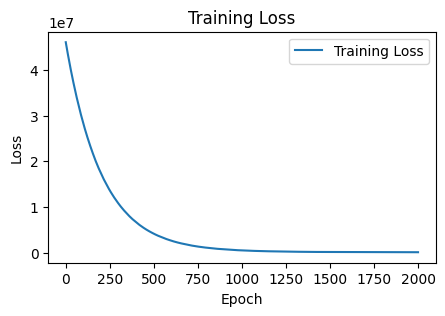

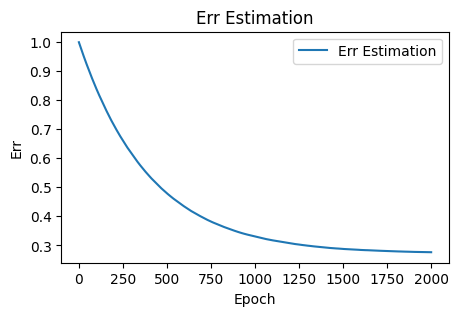

In [10]:
device = 'cuda:5'
p = 0.75
print(d1)
print(d2)
print(p)
if dataset == 'random':
    if d1 == 5000:
        if p == 0.25:
            epochs = 500
            alpha = 0.1
            eta = 100
            noise = 0
        if p == 0.5:
            epochs = 500
            alpha = 0.1
            eta = 50
            noise = 0.1
        if p == 0.75:
            epochs = 2000
            alpha = 1
            eta = 50
            noise = 1
    elif d1 == 10000:
        if p == 0.25:
            epochs = 500
            alpha = 0.1
            eta = 100
            noise = 0
        if p == 0.5:
            epochs = 500
            alpha = 0.1
            eta = 100
            noise = 0
        if p == 0.75:
            epochs = 1000
            alpha = 5
            eta = 100
            noise = 10
    elif d1 == 15000:
        if p == 0.25:
            epochs = 500
            alpha = 0.1
            eta = 100
            noise = 0
        if p == 0.5:
            epochs = 500
            alpha = 0.1
            eta = 100
            noise = 0
        if p == 0.75:
            epochs = 1000
            alpha = 1
            eta = 10
            noise = 10
elif dataset == 'ml-1m':
    if p == 0.75:
        r = 30
        epochs = 1000
        alpha = 1
        eta = 100
        noise = 0.0
print(f"epochs: {epochs}")
print(f"alpha: {alpha}")
print(f"eta: {eta}")
print(f"noise: {noise}")
"""
Train for X
"""
M = torch.tensor(M).float()
mask = torch.bernoulli(torch.full((M.shape[0],), 1-p)).bool()
Omega = torch.rand(d1, d2, device = device) <= p
# observed M & norm
M = M.to(device)
observed_M = deepcopy(M) * Omega
observed_M[mask] = 0 # mask user
#observed_M = M
#observed_M_norm, scale_M = svd_norm(observed_M) # svd norm
MTM = observed_M.t() @ observed_M
norm = torch.norm(MTM)
#MTM /= norm

scale_diag = (p - 1) / (p ** 2) * torch.diag(MTM).diag() # objective matrix
A = scale_diag + 1 / (p ** 2) * MTM

print(f"norm of M: {torch.norm(M)}")

runs = 5
X_list = []
for run in range(runs):
    # parameters setting
    X = torch.randn(d2, d2, requires_grad=True, device=device)
    #X = torch.tensor(MTM, requires_grad=True)

    loop = tqdm(range(epochs))
    #eta = 1 / np.sqrt(epochs)
    optimizer = optim.SGD([X], lr=eta)

    # opt
    train_losses = []
    err_estimates = []
    #writer = SummaryWriter('runs/'+dataset)
    for i in loop:
        loss = ((X - A)**2).mean() # mse loss
        with torch.no_grad():
            U, D, Vt = torch.linalg.svd(X.detach(), full_matrices=False)
        loss.backward()

        noise_matrix = torch.normal(mean=0, std=noise, size=(d2, d2), device=device)

        X.grad = X.grad + alpha * U @ Vt + noise_matrix # alg
        """
        with torch.no_grad():
            X.data += -eta*X.grad
        """
        optimizer.step()
        X.grad.zero_()
        #print(loss.item())
        #writer.add_scalar('Loss', loss.item(), i)
        train_losses.append(loss.item())
        err = X - M.T @ M
        err_estimates.append((torch.norm(err)/torch.norm(M.T @ M)).item())
        loop.set_postfix_str('In epoch {}, loss: {:.3f})'.format(i, loss.item()))
    X_list.append(X.detach())

plt.figure(figsize=(5, 3))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

plt.figure(figsize=(5, 3))
plt.plot(err_estimates, label='Err Estimation')
plt.xlabel('Epoch')
plt.ylabel('Err')
plt.title('Err Estimation')
plt.legend()

#np.save(f'temp2/train_loss_{str(alpha)}.npy', train_losses)
#np.save(f'temp2/err_estimates_{str(alpha)}.npy', err_estimates)

In [11]:
"""
normalization for result
"""
"""
device = 'cpu'
X = X.to(device)
M = M.to(device)
"""
G_list = []
for X in X_list:
#X, _ = svd_norm(X)
#u, d, vt = torch.linalg.svd(X)
#X = vt.t() @ vt

    err = X - M.T @ M

    #print(f"x - mtm: {X - M.T @ M}")

    print(torch.norm(err), torch.norm(M.T @ M))
    print(torch.norm(X))
    print(torch.norm(err)/torch.norm(M.T @ M))
    G_list.append(torch.norm(err)/torch.norm(M.T @ M).item())
#print(f"norm of X: {torch.norm(X)}")
#print(f"norm of M: {torch.norm(M.T @ M)}")
print(np.mean(G_list))
print(np.std(G_list))

tensor(505711.9688, grad_fn=<LinalgVectorNormBackward0>) tensor(1826976.3750)
tensor(1328359.1250, grad_fn=<LinalgVectorNormBackward0>)
tensor(0.2768, grad_fn=<DivBackward0>)


In the case r=1, use every column to recover M independently. If M can be retrieved, the result should be similar in every column.

The key is the gap between estimated r and real r

In [13]:
miss_users = torch.tensor(range(M.shape[0]))[mask]

#X = M.t() @ M
#mat = torch.randn(d2,d2, device=device)
#_, S, item_vector = top_r_svd(mat, r)
#_, S, item_vector = top_r_svd(M.t() @ M, r)
_, S, item_vector = top_r_svd(X, r)
#item_vector, S = top_r_eigen(X, r)
#item_vector = item_vector * torch.sqrt(S)
V, S, Vt = torch.linalg.svd(A, full_matrices=True)
"""
Vr = V[:, :r]  
Sr = S[:r]   
Vtr = Vt[:r, :]
"""
predict_matrix = []
miss_item_u = []
error_list = []
test_num = 0
runs = 5
result_list = []
for run in range(runs):
    for i in tqdm(range(miss_users.shape[0])):
    #for i in range(5):
        """
        M_u: 1*d2
        item_vector: r*d2
        useR_vector: 1*r
        """
        
        M_u = M[miss_users][i].float()
        non_zero_indices = M_u.nonzero(as_tuple=True)[0]

        train_idx = []
        test_idx = []
        for idx in non_zero_indices:
            if Omega[i][idx]:
                train_idx.append(idx.item())
            else:
                test_idx.append(idx.item())
        #print(non_zero_indices)
        #print(f"M_u: {M_u[non_zero_indices]}")
        # train mask
        M_u = M_u.unsqueeze(0)
        n = non_zero_indices.shape[0]
        
        #num_to_select = max(r, int(n * p))
        # 选取num_to_select个元素的下标
        #selected_indices = non_zero_indices[torch.tensor(train_idx)]
        selected_indices = torch.tensor(train_idx)
        # 获取未被选出的下标
        #non_selected_indices = non_zero_indices[torch.tensor(test_idx)]
        non_selected_indices = torch.tensor(test_idx)
        test_num += len(test_idx)
        #print(f"test_num: {test_num}")

        train_A = item_vector[:, selected_indices]
        train_B = M_u[:, selected_indices]
        #train_A = item_vector[:, non_zero_indices]
        #train_B = M_u[:, non_zero_indices]
        test_A = item_vector[:, non_selected_indices]
        test_B = M_u[:, non_selected_indices]

        # 正则化参数
        lambda_reg = 0.01
        I = torch.eye(train_A.shape[0], device=device) * lambda_reg

        # 岭回归求解
        u = torch.linalg.lstsq(train_A @ train_A.t() + I, train_A @ train_B.t()).solution.t()

        #u = torch.linalg.lstsq(train_A.t(), train_B.t()).solution.t()
        #u = train_opt(A=train_A, B=train_B, C=None, max_value=5, min_value=0)
        #u = constrain_opt(A=train_A.t(), B=train_B.t(), C=test_A.t(), r=r, max_value=5, min_value=0).float().to(device)
        #print(u.shape)
        #print(f"train_A: {train_A}")
        #print(f"train_A: {train_B}")
        #print(f"train_A: {test_A}")
        #print(f"train_A: {test_B}")
        #print(f"u: {u}")
        """
        print(u @ train_A)
        print(f"train loss: {u @ train_A - train_B}")
        print(f"predict: {u @ test_A}")
        print(f"label: {M_u[:,non_selected_indices]}")
        print(f"ALL predict: {u @ item_vector[:, non_zero_indices]}")
        print(f"ALL label: {M_u[:, non_zero_indices]}")
        """
        error_list.append(torch.sum((u @ test_A - test_B)**2).item())
        #error_list.append(torch.sum((u @ item_vector[:, non_zero_indices] - M_u[:, non_zero_indices])**2).item())
        #print()
        
    ret = np.sqrt(np.sum(error_list)/test_num)
    result_list.append(np.sqrt(np.sum(error_list)/test_num))
print(np.mean(result_list))
print(np.std(result_list))




100%|██████████| 1262/1262 [00:08<00:00, 143.53it/s]

0.17192082595730804
1.6805551804435383e-10
